In [96]:
#import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [39]:
#load dataset and view
file_path = r'C:\Users\user\Downloads\Train.csv'
data = pd.read_csv(file_path)

In [41]:
data.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


Explore Data
Checking Shape,Info,Missing Values

In [15]:
data.shape

(23524, 13)

In [60]:
data.describe(include='all')

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
count,23524,23524.000000,23524,23524,23524,23524,23524.000000,23524.000000,23524,23524,23524,23524,23524
unique,4,NaN,8735,2,2,2,NaN,NaN,2,6,5,6,10
top,Rwanda,NaN,uniqueid_1,No,Rural,Yes,NaN,NaN,Female,Head of Household,Married/Living together,Primary education,Self employed
freq,8735,NaN,4,20212,14343,17454,NaN,NaN,13877,12831,10749,12791,6437
mean,NaN,2016.975939,NaN,NaN,NaN,NaN,3.797483,38.805220,NaN,NaN,NaN,NaN,NaN
std,NaN,0.847371,NaN,NaN,NaN,NaN,2.227613,16.520569,NaN,NaN,NaN,NaN,NaN
min,NaN,2016.000000,NaN,NaN,NaN,NaN,1.000000,16.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,2016.000000,NaN,NaN,NaN,NaN,2.000000,26.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,2017.000000,NaN,NaN,NaN,NaN,3.000000,35.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,2018.000000,NaN,NaN,NaN,NaN,5.000000,49.000000,NaN,NaN,NaN,NaN,NaN


In [17]:
data.info

<bound method DataFrame.info of       country  year       uniqueid bank_account location_type  \
0       Kenya  2018     uniqueid_1          Yes         Rural   
1       Kenya  2018     uniqueid_2           No         Rural   
2       Kenya  2018     uniqueid_3          Yes         Urban   
3       Kenya  2018     uniqueid_4           No         Rural   
4       Kenya  2018     uniqueid_5           No         Urban   
...       ...   ...            ...          ...           ...   
23519  Uganda  2018  uniqueid_2113           No         Rural   
23520  Uganda  2018  uniqueid_2114           No         Rural   
23521  Uganda  2018  uniqueid_2115           No         Rural   
23522  Uganda  2018  uniqueid_2116           No         Urban   
23523  Uganda  2018  uniqueid_2117           No         Rural   

      cellphone_access  household_size  age_of_respondent  \
0                  Yes               3                 24   
1                   No               5                 70   
2   

Handling Missing Values

In [35]:
data.isnull().sum()

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

In [107]:
# fill values in numerical columns with the median
data.fillna(data.median(numeric_only=True), inplace=True)

# fill missing categorical columns with the mode
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# verify if missing values were handled well
data.isnull().sum()

year                             0
bank_account                     0
household_size                   0
age_of_respondent                0
country_Rwanda                   0
                                ..
job_type_Informally employed     0
job_type_No Income               0
job_type_Other Income            0
job_type_Remittance Dependent    0
job_type_Self employed           0
Length: 8767, dtype: int64

Visualize Data (EDA)

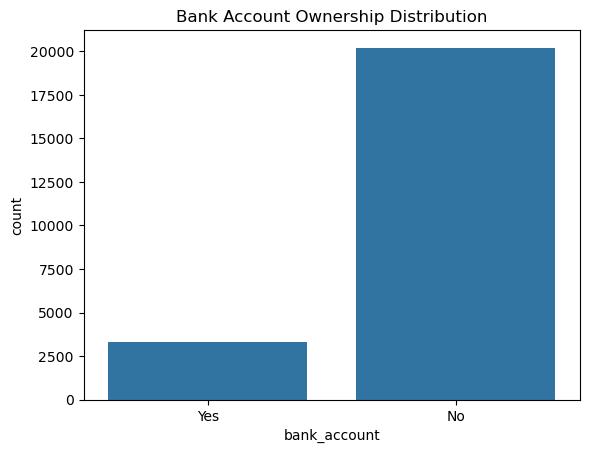

In [39]:
#check target variable distribution (bank account ownership)
sns.countplot(x='bank_account', data=data)
plt.title('Bank Account Ownership Distribution')
plt.show()

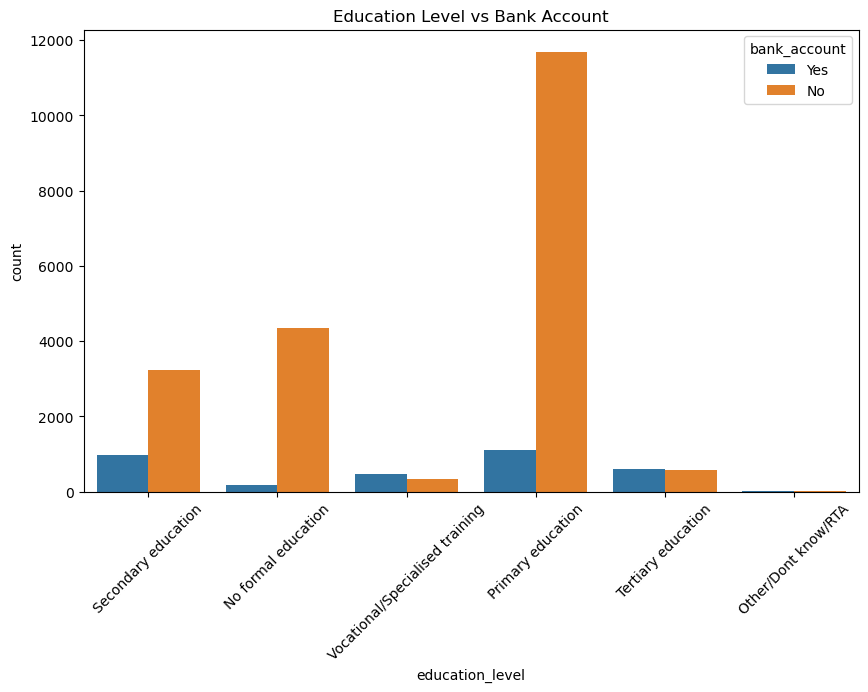

In [43]:
#Plotting Categorical variables to find patterns
plt.figure(figsize=(10, 6))
sns.countplot(x='education_level', hue='bank_account', data=data)
plt.xticks(rotation=45)
plt.title('Education Level vs Bank Account')
plt.show()

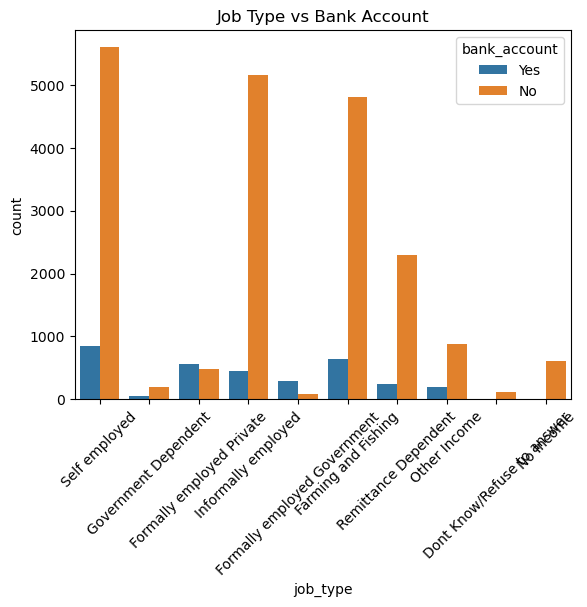

In [70]:
sns.countplot(x='job_type', hue='bank_account', data=data)
plt.xticks(rotation=45)
plt.title('Job Type vs Bank Account')
plt.show()

In [45]:
data.tail()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
23519,Uganda,2018,uniqueid_2113,No,Rural,Yes,4,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114,No,Rural,Yes,2,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115,No,Rural,Yes,5,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116,No,Urban,Yes,7,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed
23523,Uganda,2018,uniqueid_2117,No,Rural,Yes,10,20,Male,Child,Single/Never Married,Secondary education,No Income


Encode Categorical Data

In [49]:
#Encode target column (bank_account)
le = LabelEncoder()
data['bank_account'] = le.fit_transform(data['bank_account'])

#seperate target variable before encoding
target = data['bank_account']
features = data.drop('bank_account', axis=1)

#one-hot encode only features
data_encoded = pd.get_dummies(features, drop_first=True)

#Join back the target column
data_encoded['bank_account'] = target

Standard Scaler

In [81]:
scaler = StandardScaler()
X_all = data_encoded.drop('bank_account', axis=1)
X_all = pd.DataFrame(scaler.fit_transform(x_all), columns=x_all.columns)

Split Data for Training and Testing

In [83]:
#Split the data into 70% taining, 30% testing
y = data_encoded['bank_account']
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=43)

Train and Evualate Model

In [94]:
#Train the model
print("Trainingthe model...")
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_all, y_train)
print("Model training completed.")

#make predictions
print("making predictions...")
y_pred_all = model_all.predict(X_test_all)
print("Predictions completed.")

#Evaluate the model
print("\nAccuracy (All Features Scaled):", accuracy_score(y_test, y_pred_all))
print("\nclassification Report (All Features Scaled):\n", classification_report(y_test, y_pred_all))

Trainingthe model...
Model training completed.
making predictions...
Predictions completed.

Accuracy (All Features Scaled): 0.8061773873618588

classification Report (All Features Scaled):
               precision    recall  f1-score   support

           0       0.89      0.88      0.89      6057
           1       0.32      0.33      0.33      1001

    accuracy                           0.81      7058
   macro avg       0.61      0.61      0.61      7058
weighted avg       0.81      0.81      0.81      7058

